# Visualização dos dados

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)

## Bibliotecas

In [14]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

## Funções

In [2]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []
    target_df = None

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
            target_df.columns = ["timestamp", "target"]
        else:
            sensor_id = int(re.search(r"\d+", file.stem).group())
            
            df = pd.read_csv(file)
            df.columns = ["timestamp", f"sensor_{sensor_id}"]

            feature_dfs.append(df)
    
    feature_dfs.sort(
        key=lambda df: int(df.columns[1].split("_")[1])
    )
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

In [3]:
def plotar_sensores(
    df,
    sensores=None,
    modo="juntos",
    normalizar=True,
    ncols=4,
    resample=None,
    figsize=None
):
    """
    Plota séries temporais dos sensores e os limites dos períodos de falha.

    Args:
        df: DataFrame com índice temporal, sensores e target.
        sensores: Lista de sensores. None seleciona todos.
        modo: "juntos" ou "separados".
        normalizar: Normaliza cada sensor utilizando z-score.
        ncols: Número de colunas no modo "separados".
        resample: Frequência opcional para reduzir os dados, como "10min".
        figsize: Tamanho personalizado da figura.

    Returns:
        fig, axes
    """
    todos_sensores = sorted(
        [
            coluna for coluna in df.columns
            if re.fullmatch(r"sensor_\d+", coluna)
        ],
        key=lambda coluna: int(coluna.split("_")[1])
    )

    if sensores is None:
        sensores = todos_sensores
    elif isinstance(sensores, str):
        sensores = [sensores]

    dados = df[sensores].copy()

    if normalizar:
        media = dados.mean()
        desvio = dados.std().replace(0, float("nan"))
        dados = (dados - media) / desvio

    # Redução opcional apenas para tornar o gráfico mais leve
    if resample is not None:
        dados = dados.resample(resample).mean()

    target = df["target"].fillna(0).astype(int)

    inicios = df.index[
        target.eq(1)
        & target.shift(fill_value=0).eq(0)
    ]

    finais = df.index[
        target.eq(1)
        & target.shift(-1, fill_value=0).eq(0)
    ]

    def adicionar_falhas(ax, adicionar_label=False):
        for inicio in inicios:
            ax.axvline(
                inicio,
                color="red",
                linestyle="--",
                linewidth=1.2,
                alpha=0.7,
                label="Início da falha" if adicionar_label else None
            )
            adicionar_label = False

        primeiro_final = True

        for final in finais:
            ax.axvline(
                final,
                color="black",
                linestyle="--",
                linewidth=1.2,
                alpha=0.7,
                label="Fim da falha" if primeiro_final else None
            )
            primeiro_final = False

    ylabel = "Valor padronizado (z-score)" if normalizar else "Valor do sensor"

    if modo == "juntos":
        if figsize is None:
            figsize = (20, 8)

        fig, ax = plt.subplots(figsize=figsize)

        # Mostra nomes na legenda apenas para subconjuntos pequenos
        mostrar_sensores_legenda = len(sensores) <= 10

        for sensor in sensores:
            ax.plot(
                dados.index,
                dados[sensor],
                linewidth=0.6,
                alpha=0.6,
                label=sensor if mostrar_sensores_legenda else None
            )

        adicionar_falhas(ax, adicionar_label=True)

        ax.set_title("Comportamento dos sensores e períodos de falha")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel(ylabel)
        ax.margins(x=0)
        ax.legend()

        plt.tight_layout()
        plt.show()

        return fig, ax

    # Modo separado
    quantidade = len(sensores)
    nrows = (quantidade + ncols - 1) // ncols

    if figsize is None:
        figsize = (20, 2.2 * nrows)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=True,
        squeeze=False
    )

    axes_flat = axes.ravel()

    for i, sensor in enumerate(sensores):
        ax = axes_flat[i]

        ax.plot(
            dados.index,
            dados[sensor],
            linewidth=0.7
        )

        adicionar_falhas(
            ax,
            adicionar_label=(i == 0)
        )

        ax.set_title(sensor, fontsize=10)
        ax.grid(alpha=0.2)
        ax.margins(x=0)

    # Remove axes excedentes quando a quantidade não fecha a grade
    for ax in axes_flat[quantidade:]:
        ax.remove()

    handles, labels = axes_flat[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2
    )

    fig.suptitle(
        "Comportamento individual dos sensores",
        fontsize=15
    )
    fig.supxlabel("Timestamp")
    fig.supylabel(ylabel)

    plt.tight_layout(rect=(0.02, 0.02, 1, 0.97))
    plt.show()

In [12]:
def plotar_distribuicoes_sensores(
    df,
    sensores=None,
    bins=50,
    normalizar=False,
    comparar_target=False,
    ncols=4,
    density=False,
    figsize=None
):
    """
    Plota histogramas das distribuições dos sensores.

    Args:
        df: DataFrame contendo sensores e target.
        sensores: Sensor ou lista de sensores. None seleciona todos.
        bins: Número de intervalos do histograma.
        normalizar: Aplica z-score separadamente em cada sensor.
        comparar_target: Separa as distribuições entre NORMAL e ANORMAL.
        ncols: Número de colunas da grade.
        density: Mostra densidade em vez de frequência absoluta.
        figsize: Tamanho personalizado da figura.

    Returns:
        fig, axes
    """
    todos_sensores = sorted(
        [
            coluna for coluna in df.columns
            if re.fullmatch(r"sensor_\d+", coluna)
        ],
        key=lambda coluna: int(coluna.split("_")[1])
    )

    if sensores is None:
        sensores = todos_sensores
    elif isinstance(sensores, str):
        sensores = [sensores]

    dados = df[sensores].copy()

    if normalizar:
        medias = dados.mean()
        desvios = dados.std().replace(0, np.nan)

        dados = (dados - medias) / desvios

    quantidade = len(sensores)
    nrows = int(np.ceil(quantidade / ncols))

    if figsize is None:
        figsize = (5 * ncols, 3 * nrows)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False
    )

    axes_flat = axes.ravel()

    for i, sensor in enumerate(sensores):
        ax = axes_flat[i]

        if comparar_target:
            valores_normal = dados.loc[
                df["target"].eq(0),
                sensor
            ].dropna()

            valores_anormal = dados.loc[
                df["target"].eq(1),
                sensor
            ].dropna()

            # Mesmos limites para os dois histogramas
            valores_completos = dados[sensor].dropna()
            limites_bins = np.histogram_bin_edges(
                valores_completos,
                bins=bins
            )

            ax.hist(
                valores_normal,
                bins=limites_bins,
                density=density,
                alpha=0.6,
                label="Normal"
            )

            ax.hist(
                valores_anormal,
                bins=limites_bins,
                density=density,
                alpha=0.6,
                label="Anormal"
            )

        else:
            ax.hist(
                dados[sensor].dropna(),
                bins=bins,
                density=density,
                alpha=0.8
            )

        ax.set_title(sensor)
        ax.set_xlabel(
            "Valor normalizado"
            if normalizar
            else "Valor do sensor"
        )
        ax.set_ylabel(
            "Densidade"
            if density
            else "Frequência"
        )

        ax.grid(axis="y", alpha=0.2)

        if comparar_target and i == 0:
            ax.legend()

    # Remove axes não utilizados
    for ax in axes_flat[quantidade:]:
        ax.remove()

    if comparar_target:
        handles, labels = axes_flat[0].get_legend_handles_labels()

        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=2
        )

    titulo = "Distribuição dos sensores"

    if normalizar:
        titulo += " — valores normalizados"

    if comparar_target:
        titulo += " por condição operacional"

    fig.suptitle(
        titulo,
        fontsize=15
    )

    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

## Carregando os dados

In [4]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)
industry_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,4.548754,90.886874,58.698896,89.301134,1011.733181,97.284889,33.248746,-10.390227,29.262578,...,101.547023,154.291476,114.466107,103.082616,119.246973,60.729332,310.022461,124.735196,426.651658,410.820484
2018-04-01 00:01:00,0,7.887998,56.555373,80.802810,120.898222,1358.466600,202.583688,32.494870,19.427739,61.038519,...,71.846296,59.239207,90.076161,93.760055,63.457947,62.910653,306.084796,158.822485,375.316113,143.620728
2018-04-01 00:02:00,0,4.975919,182.086958,87.273632,9.914782,1056.489015,147.098428,36.402837,38.900027,30.304666,...,59.174616,87.136301,99.274584,111.916792,60.560834,81.332910,353.863854,88.772027,444.809188,618.898000
2018-04-01 00:03:00,0,6.304142,58.417235,75.059520,64.167463,1619.924847,307.722320,34.283344,46.602862,44.859311,...,0.674927,110.321579,103.978381,103.705604,24.141894,36.219671,301.563110,53.387484,414.052496,427.323378
2018-04-01 00:04:00,0,1.671733,108.946809,94.910470,14.551922,591.648283,-7.684779,30.980682,39.293311,1.229287,...,71.785623,112.435498,103.170425,110.566095,53.913605,116.770552,298.957820,168.746952,431.548430,514.659884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,6.066461,128.157145,144.452803,66.621842,1791.181163,172.833101,13.116142,52.438915,32.694638,...,77.001917,105.953758,169.203415,74.959180,159.206995,98.736928,432.326663,199.902569,NaN,343.198701
2018-08-31 23:56:00,0,4.057784,-31.186502,49.775117,69.397205,1166.424000,146.161645,26.785100,17.436183,39.612008,...,32.268873,12.201309,59.127149,149.304241,26.936970,125.800942,402.294815,218.904951,NaN,381.082811
2018-08-31 23:57:00,0,6.751912,80.433446,107.038506,137.923928,1060.918628,106.901675,37.495990,20.406074,33.073722,...,87.497962,90.664739,144.615688,29.140853,118.974814,75.747273,269.339456,260.899365,NaN,452.482461


In [ ]:
industry_df.describe().T

## Visualizando dados temporais

In [5]:
timestamps = pd.to_datetime(industry_df.index)

inicio = timestamps.min()
fim = timestamps.max()
duracao = fim - inicio

print(f"Início: {inicio}")
print(f"Fim: {fim}")
print(f"Duração: {duracao}")
print(f"Total em dias: {duracao.total_seconds() / 86_400:.2f}")
print(f"Total em horas: {duracao.total_seconds() / 3_600:.2f}")
print(f"Quantidade de observações: {timestamps.nunique():,}")

Início: 2018-04-01 00:00:00
Fim: 2018-08-31 23:59:00
Duração: 152 days 23:59:00
Total em dias: 153.00
Total em horas: 3671.98
Quantidade de observações: 220,320


## Visualizando distribuição das classes

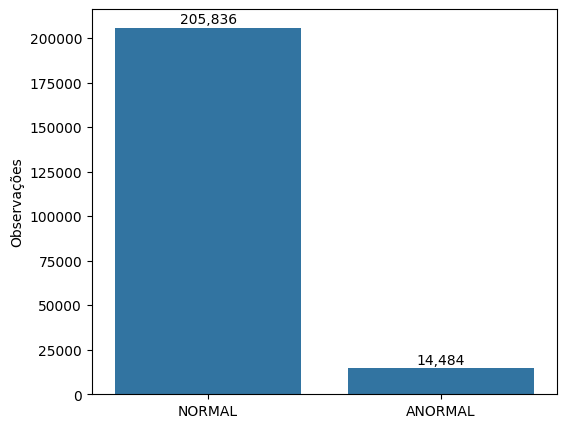

In [6]:
counts = industry_df["target"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(x=["NORMAL", "ANORMAL"], y=counts, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=1)

plt.ylabel("Observações")
plt.show()

In [7]:
percentuais = industry_df["target"].value_counts(normalize=True).sort_index().mul(100).round(2)

for classe, percentual in percentuais.items():
    nome = "NORMAL" if classe == 0 else "ANORMAL"
    print(f"{nome}: {percentual:.2f}%")

NORMAL: 93.43%
ANORMAL: 6.57%


Com essas informações podemos ver que o dataset é bem **desbalanceado**.

Podemos também ter uma visualização do estado da máquina. Momentos em que houve falha e momentos em que ela estava funcionando normalmente ao longo do tempo.

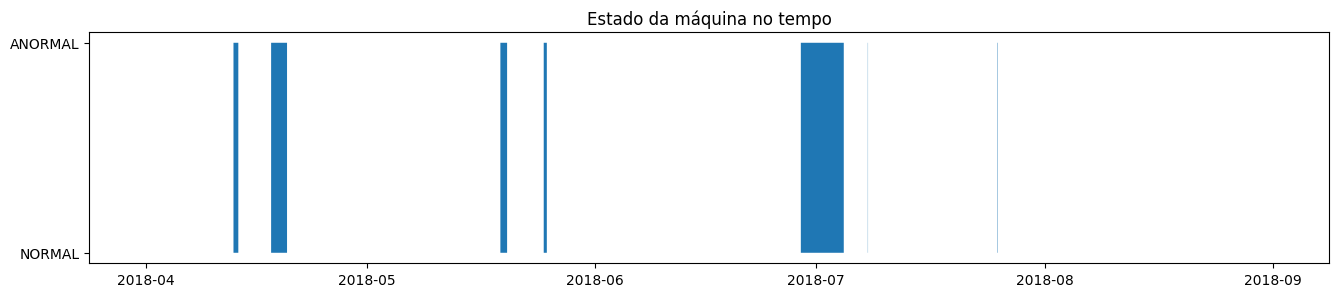

In [8]:
plt.figure(figsize=(16, 3))
plt.fill_between(industry_df.index, 0, industry_df["target"], step="post")

plt.yticks([0, 1], ["NORMAL", "ANORMAL"])
plt.title("Estado da máquina no tempo")
plt.show()

## Visualizando os sensores

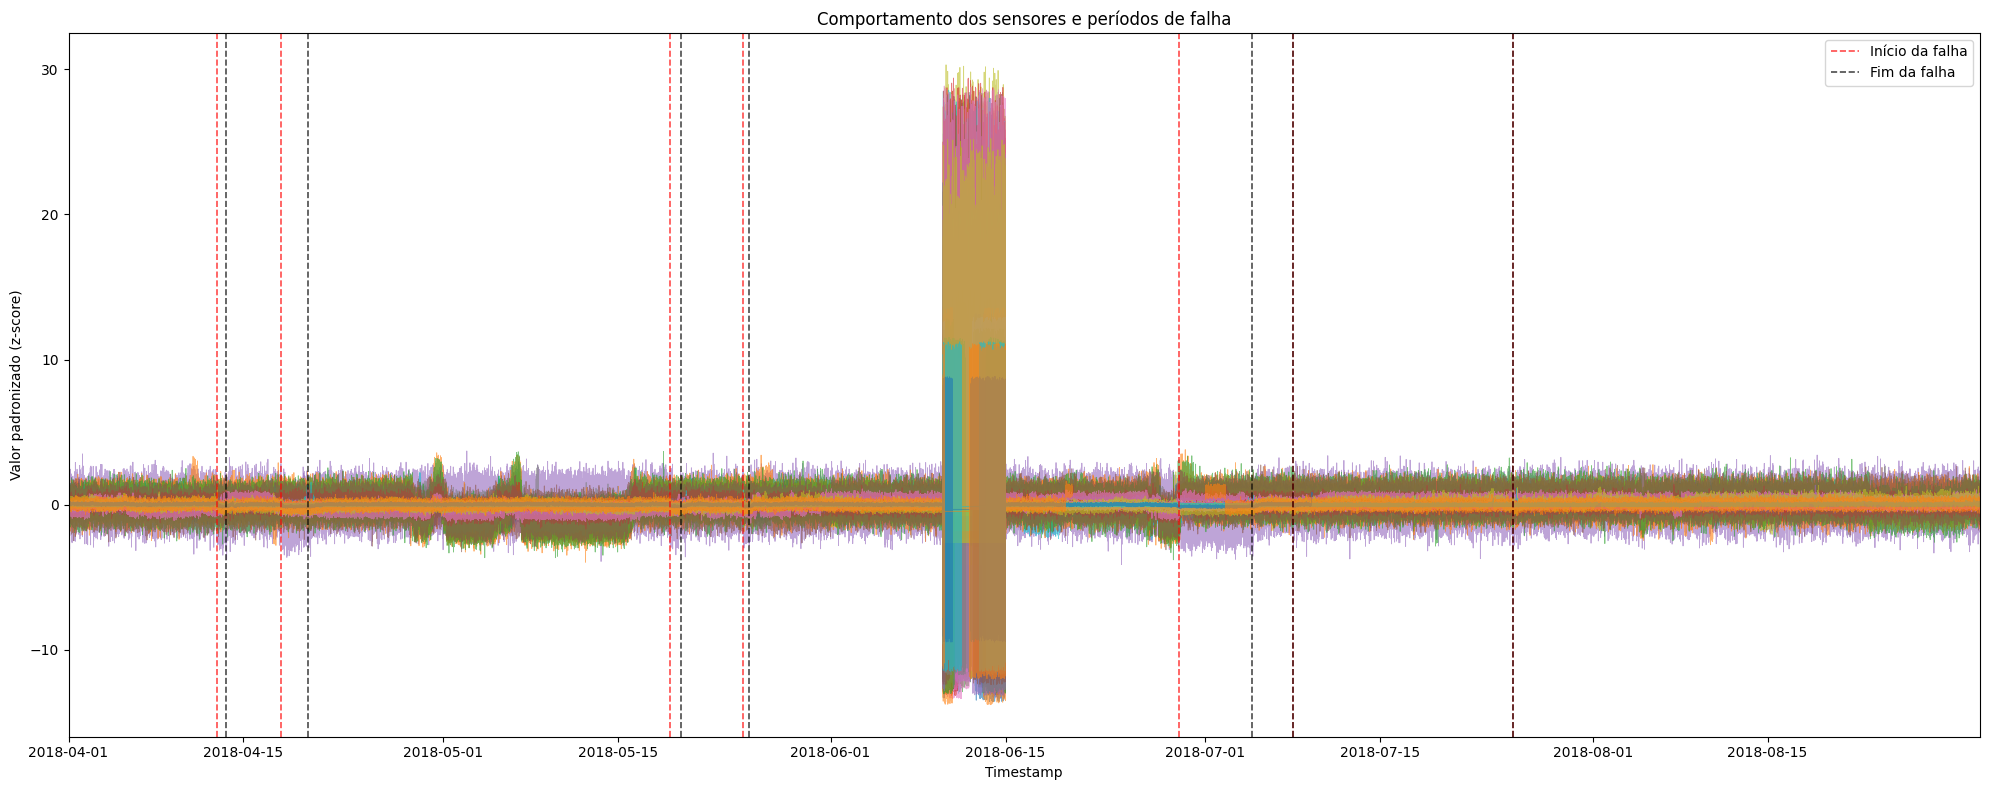

(<Figure size 2000x800 with 1 Axes>,
 <Axes: title={'center': 'Comportamento dos sensores e períodos de falha'}, xlabel='Timestamp', ylabel='Valor padronizado (z-score)'>)

In [9]:
plotar_sensores(
    industry_df,
    modo="juntos"
)

Podemos ter uma visualização inicial de cada sensor separadamente também.

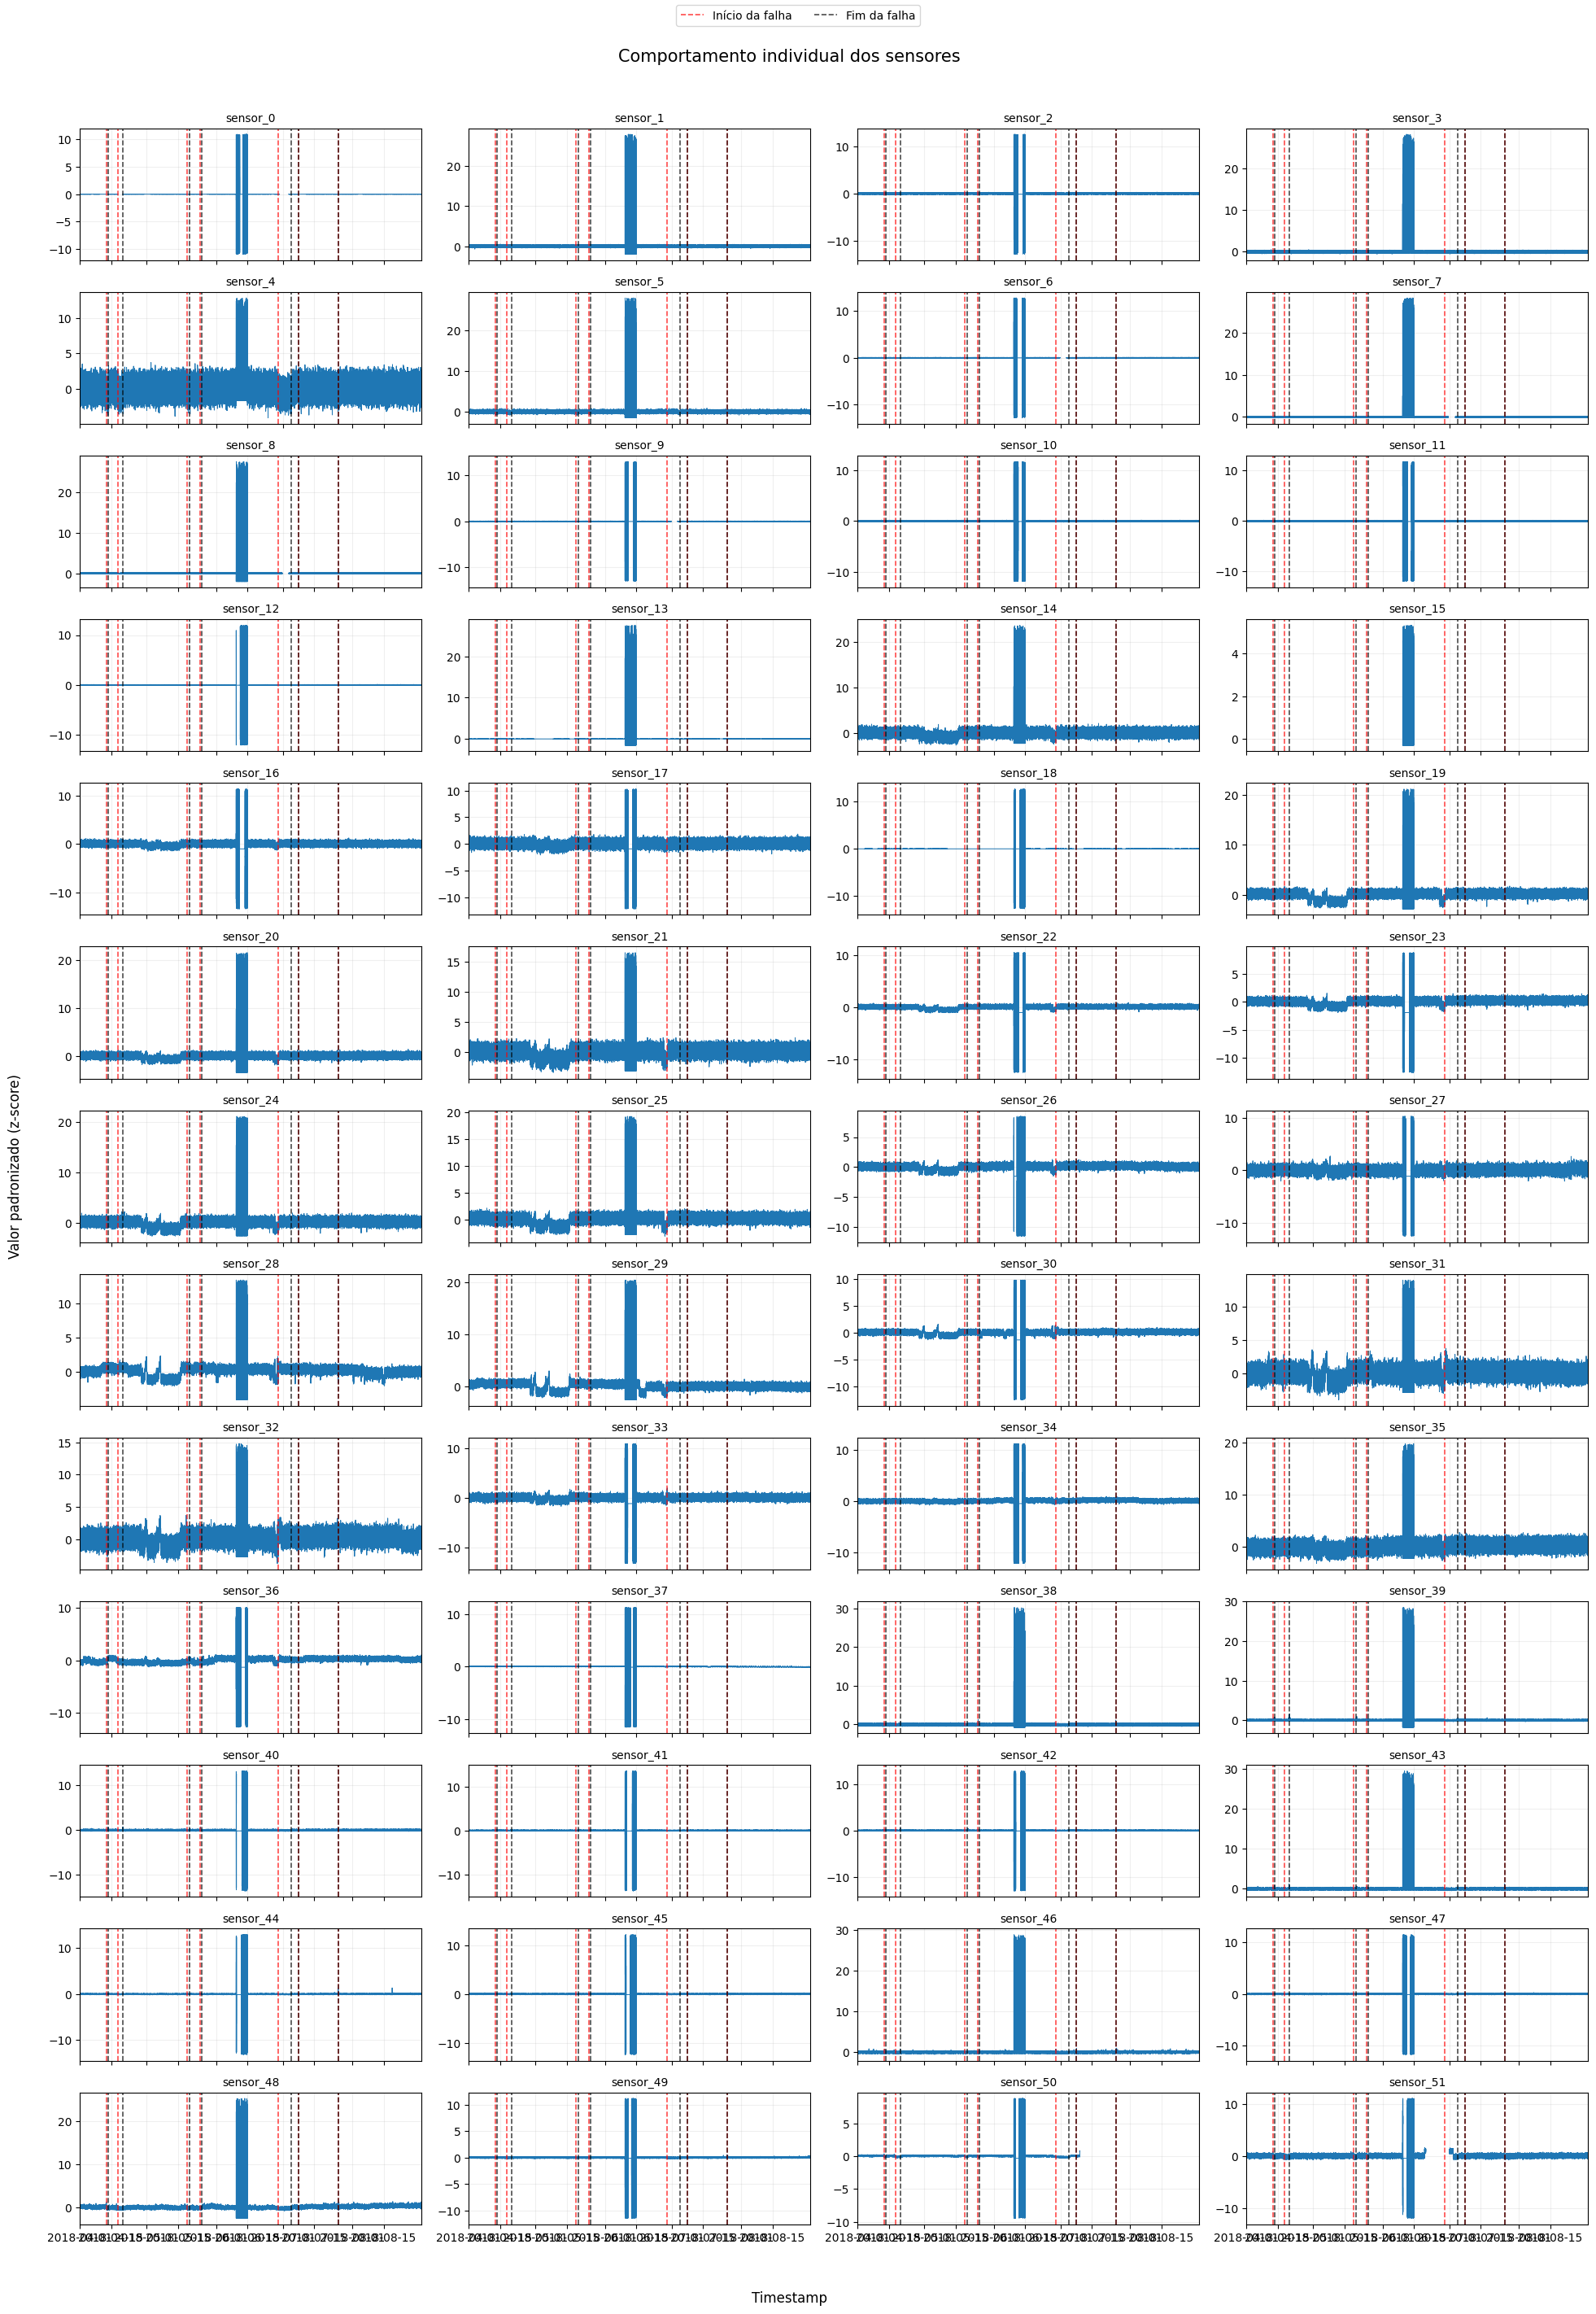

In [10]:
plotar_sensores(
    industry_df,
    modo="separados",
    ncols=4
)

Ao invés de visualizarmos apenas os valores individuais de cada sensor, podemos visualizar as médias num período de 10 minutos.

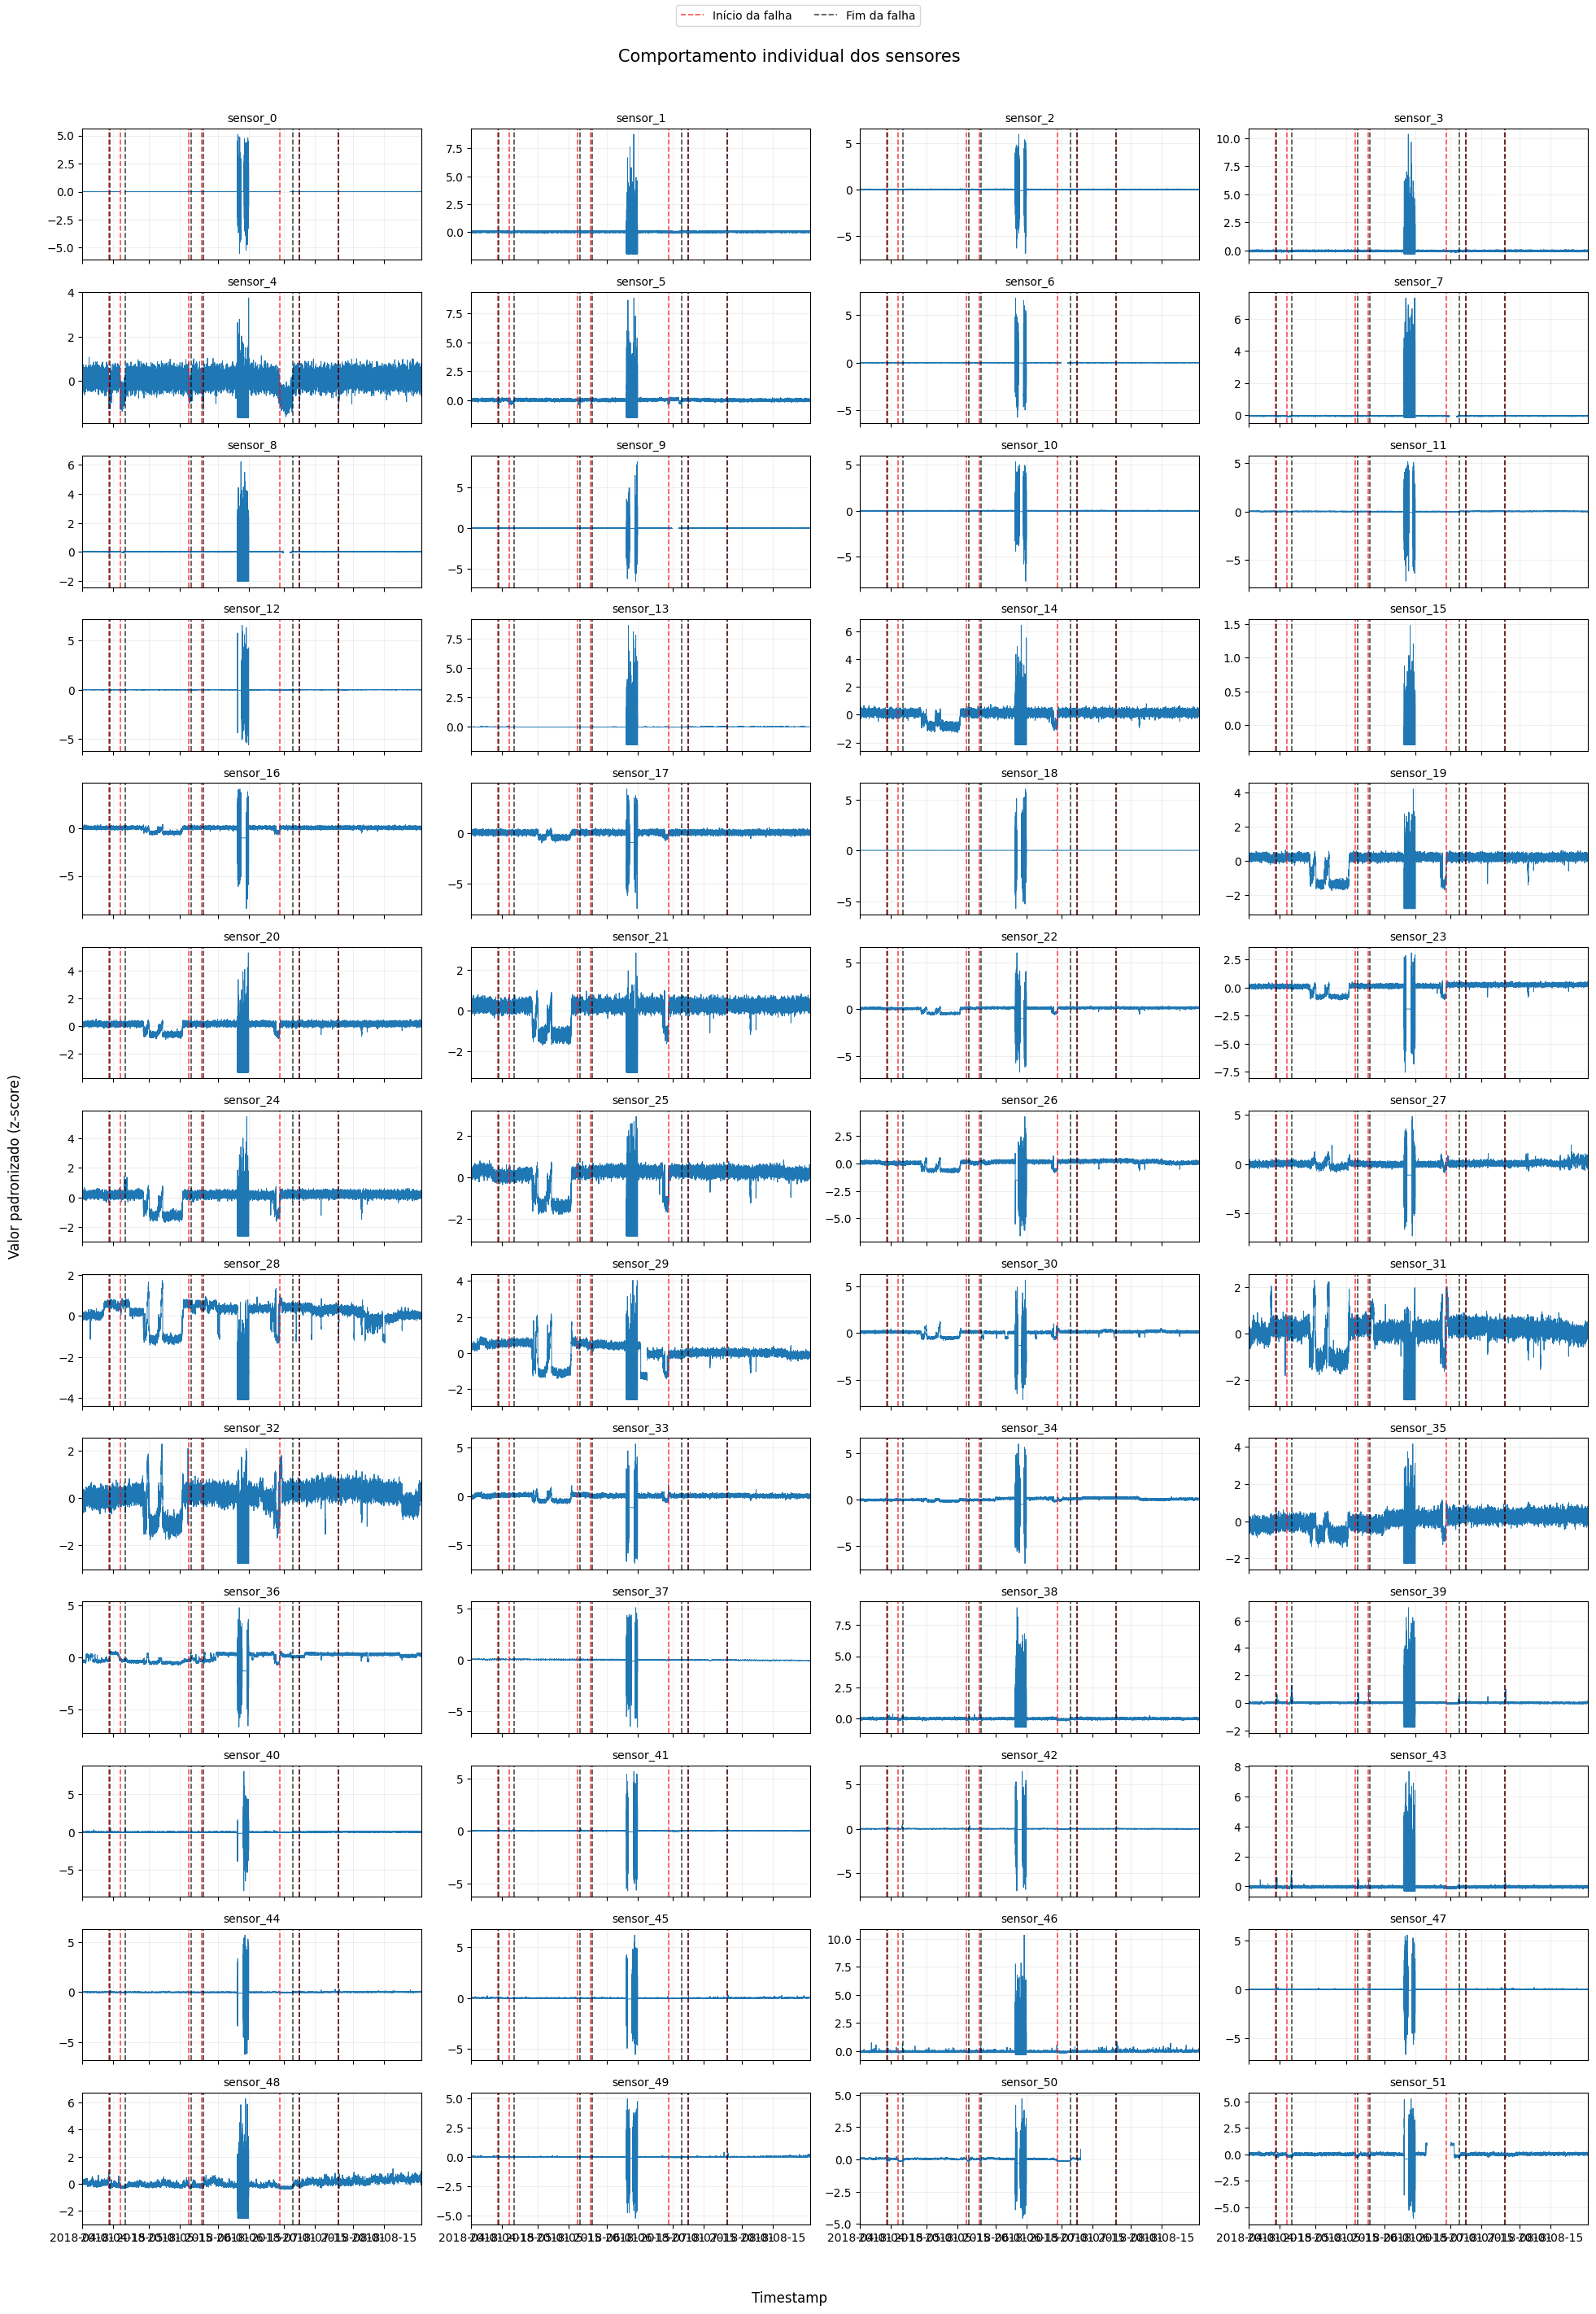

In [11]:
plotar_sensores(
    industry_df,
    modo="separados",
    ncols=4,
    resample="10min"
)

Com essa visualização das médias, é possível percebera alguns sensores com comportamentos que mudam (visualmente) em períodos anteriores a alguma falha: `sensor_4`, `sensor_14`, `sensor_19`, `sensor_20`, `sensor_21`, `sensor_22`, `sensor_23`, `sensor_24`, `sensor_25`, `sensor_26`, `sensor_27`, `sensor_28`, `sensor_29`, `sensor_30`, `sensor_31`, `sensor_32`, `sensor_33`, `sensor_34`, `sensor_35`, `sensor_36`, `sensor_48`.

Os demais sensores não fica tão evidente. Todos serão melhor investigados nos próximos notebooks.

Uma outra visualização interessante também são os histogramas de distribuição de cada um dos sensores.

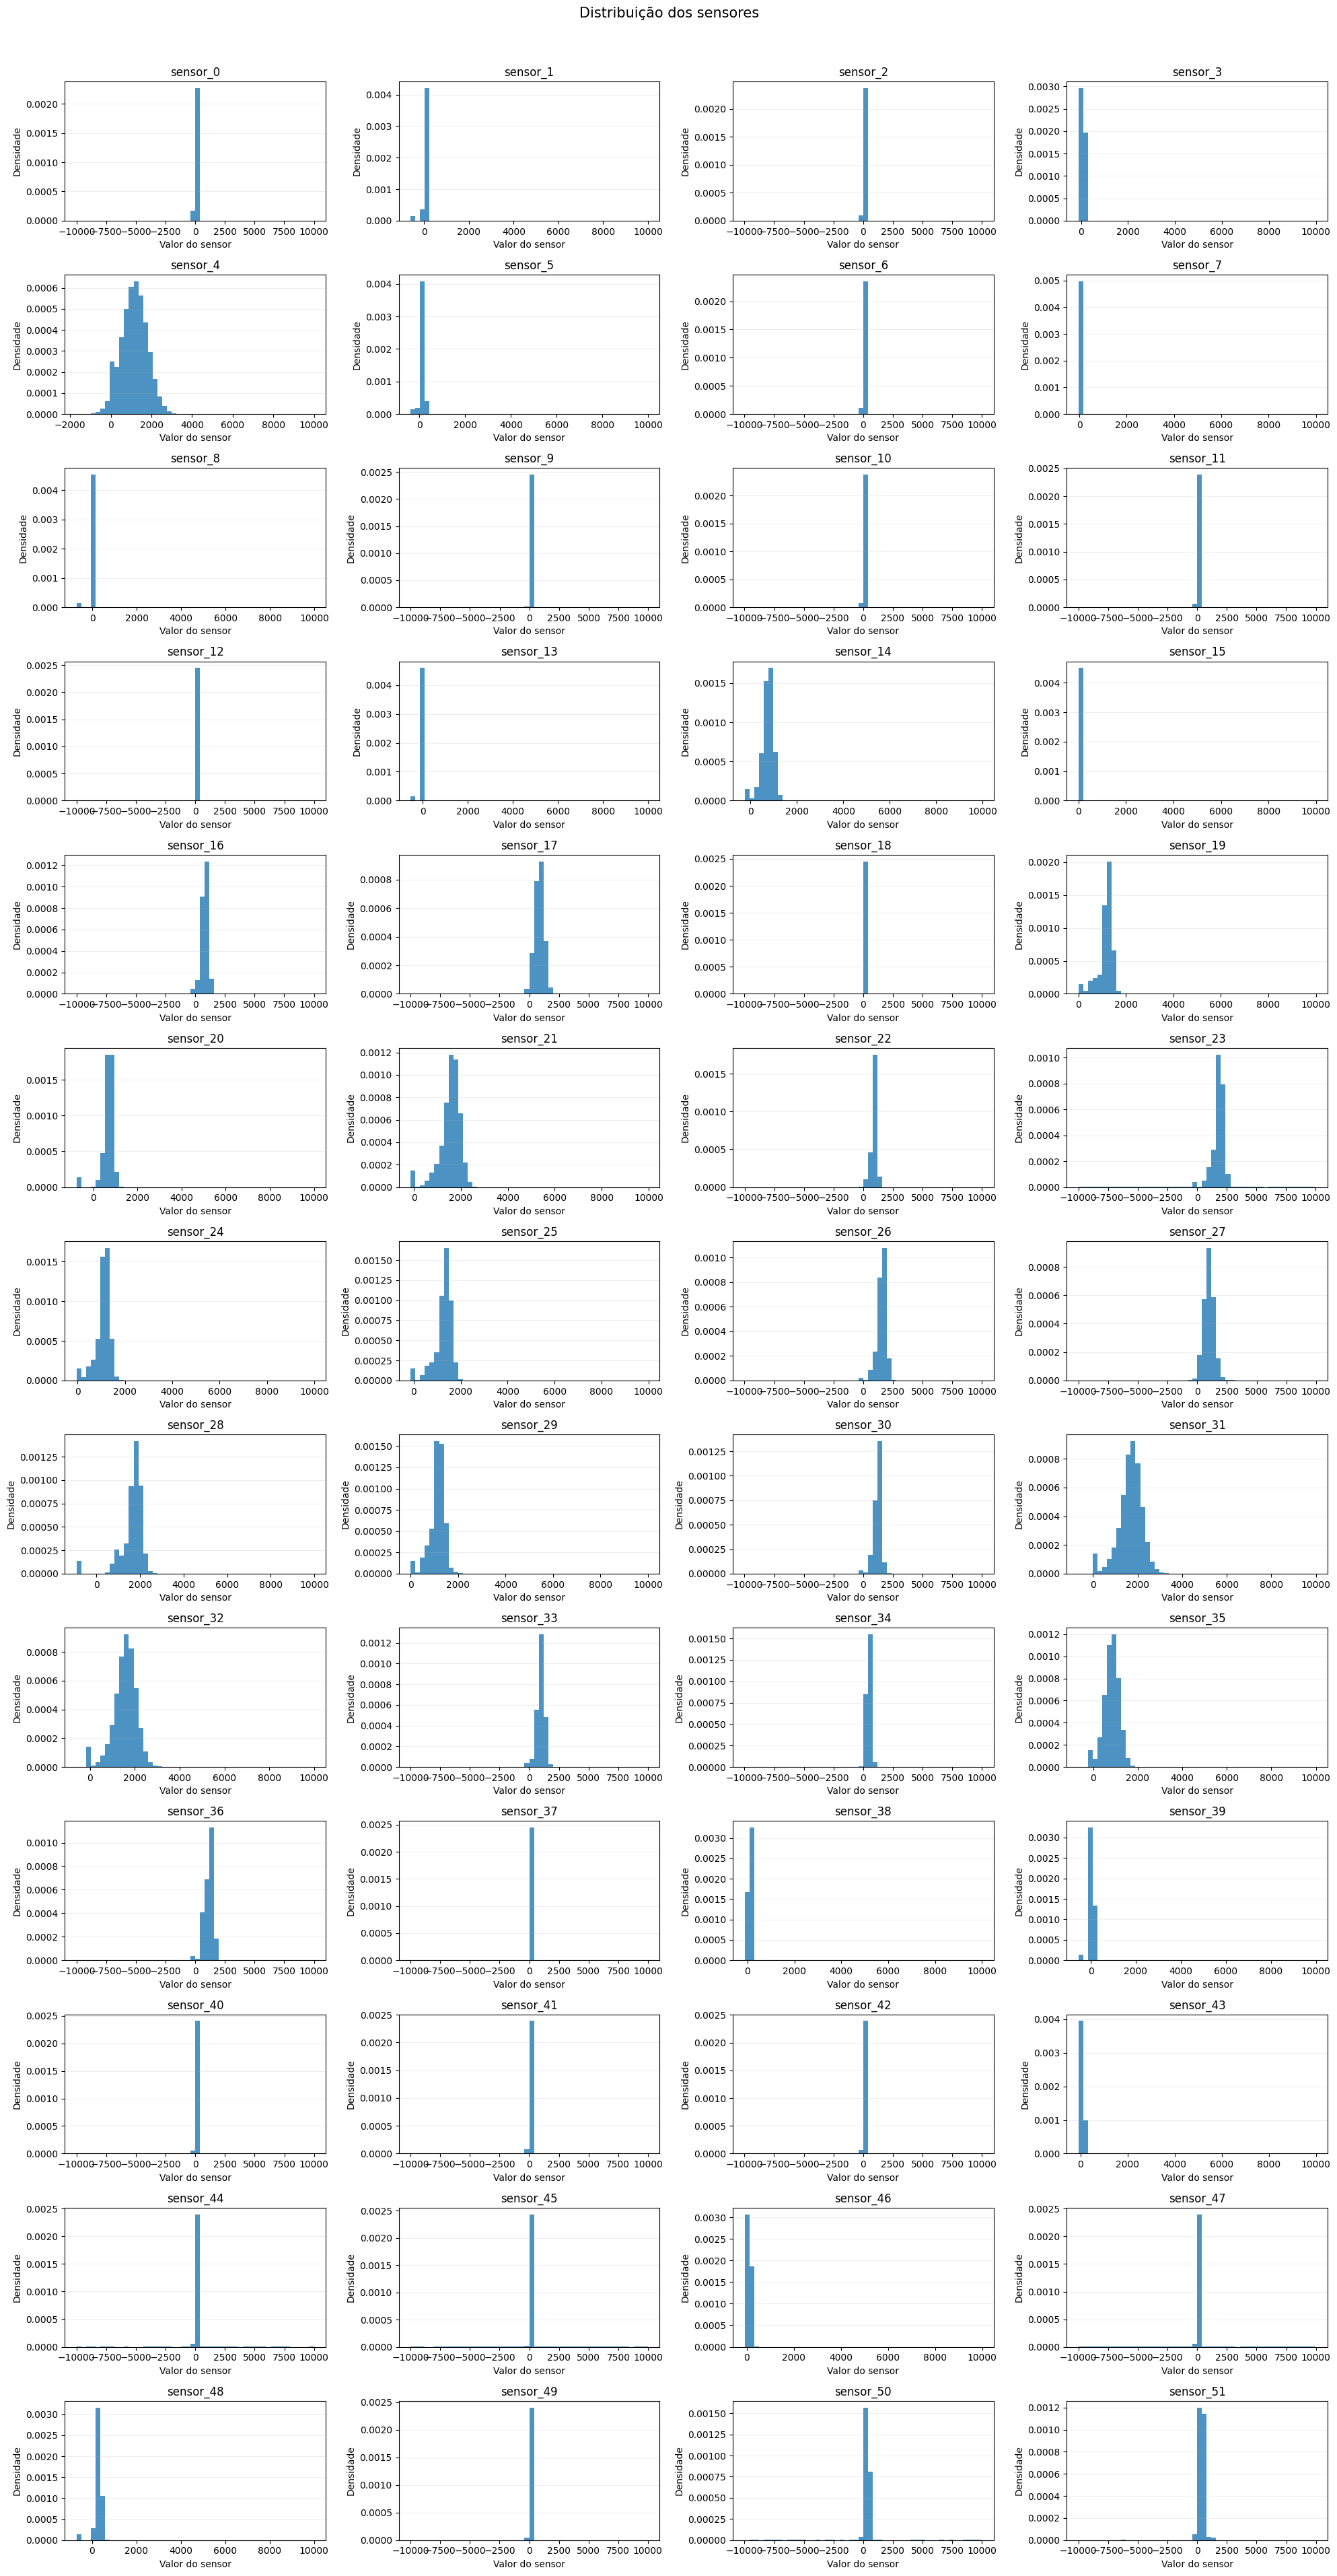

In [19]:
plotar_distribuicoes_sensores(
    industry_df,
    bins=50,
    ncols=4,
    density=True
)

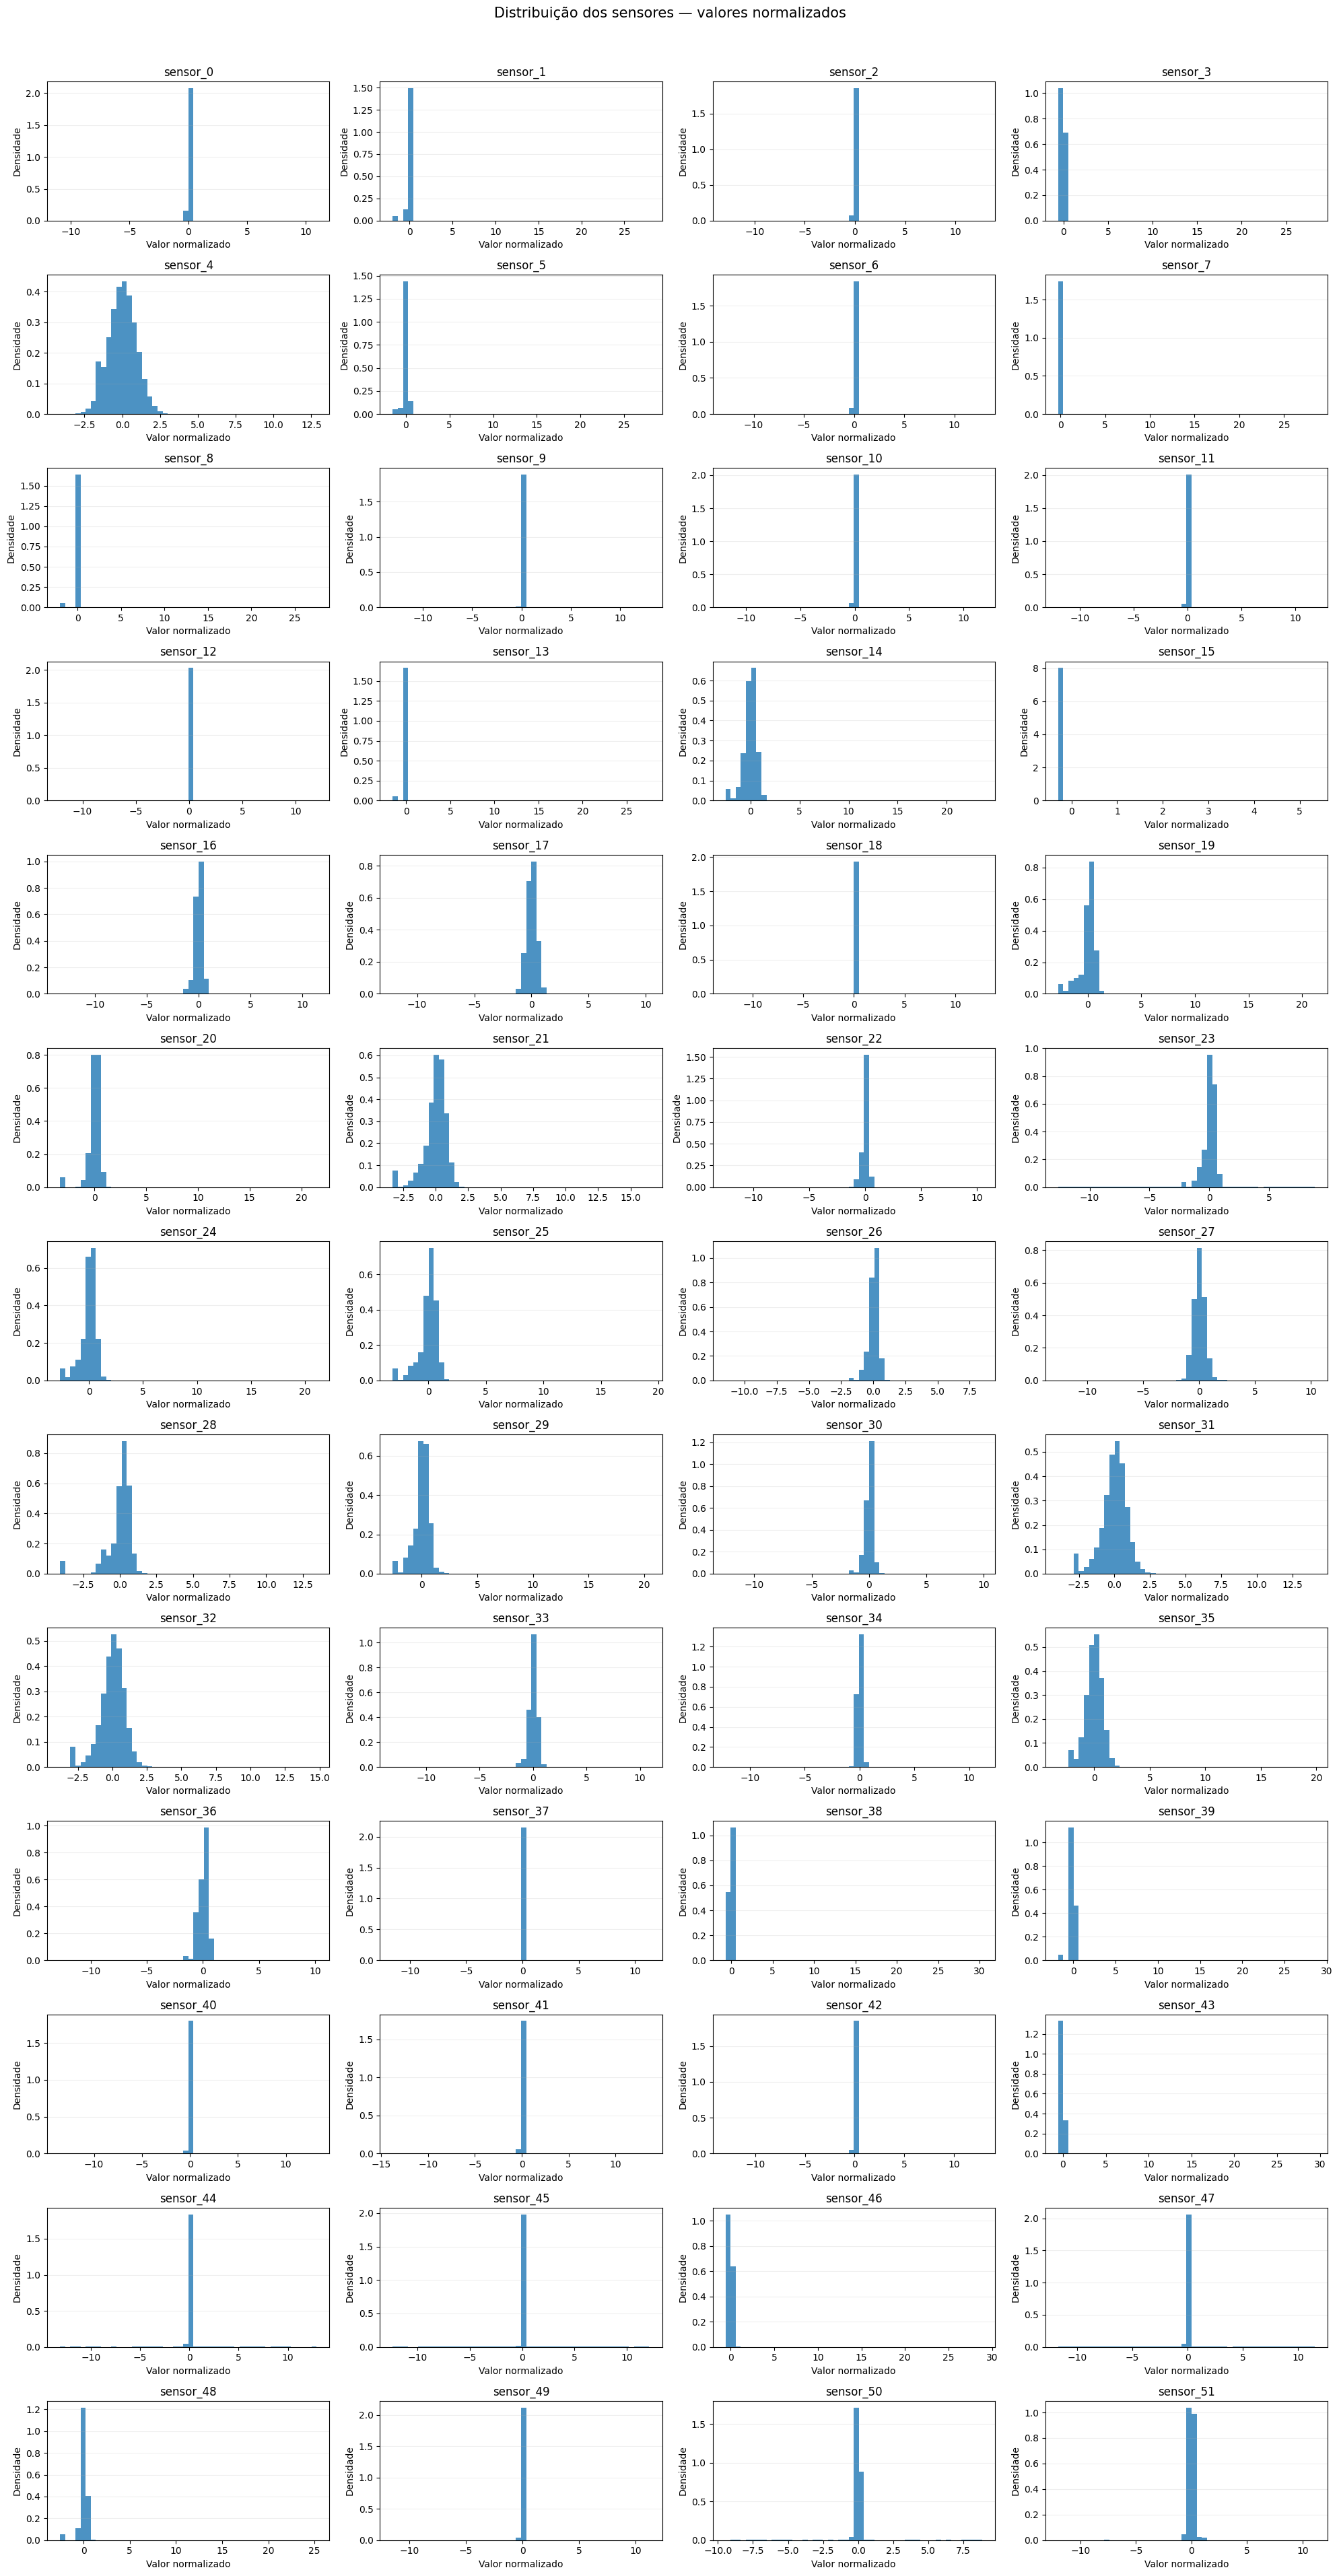

In [18]:
plotar_distribuicoes_sensores(
    industry_df,
    normalizar=True,
    bins=50,
    ncols=4,
    density=True
)

/home/miguel/Documents/processos_seletivos/desafio_tecnico_industriall/ps-industriall-estagio-ml/.venv/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


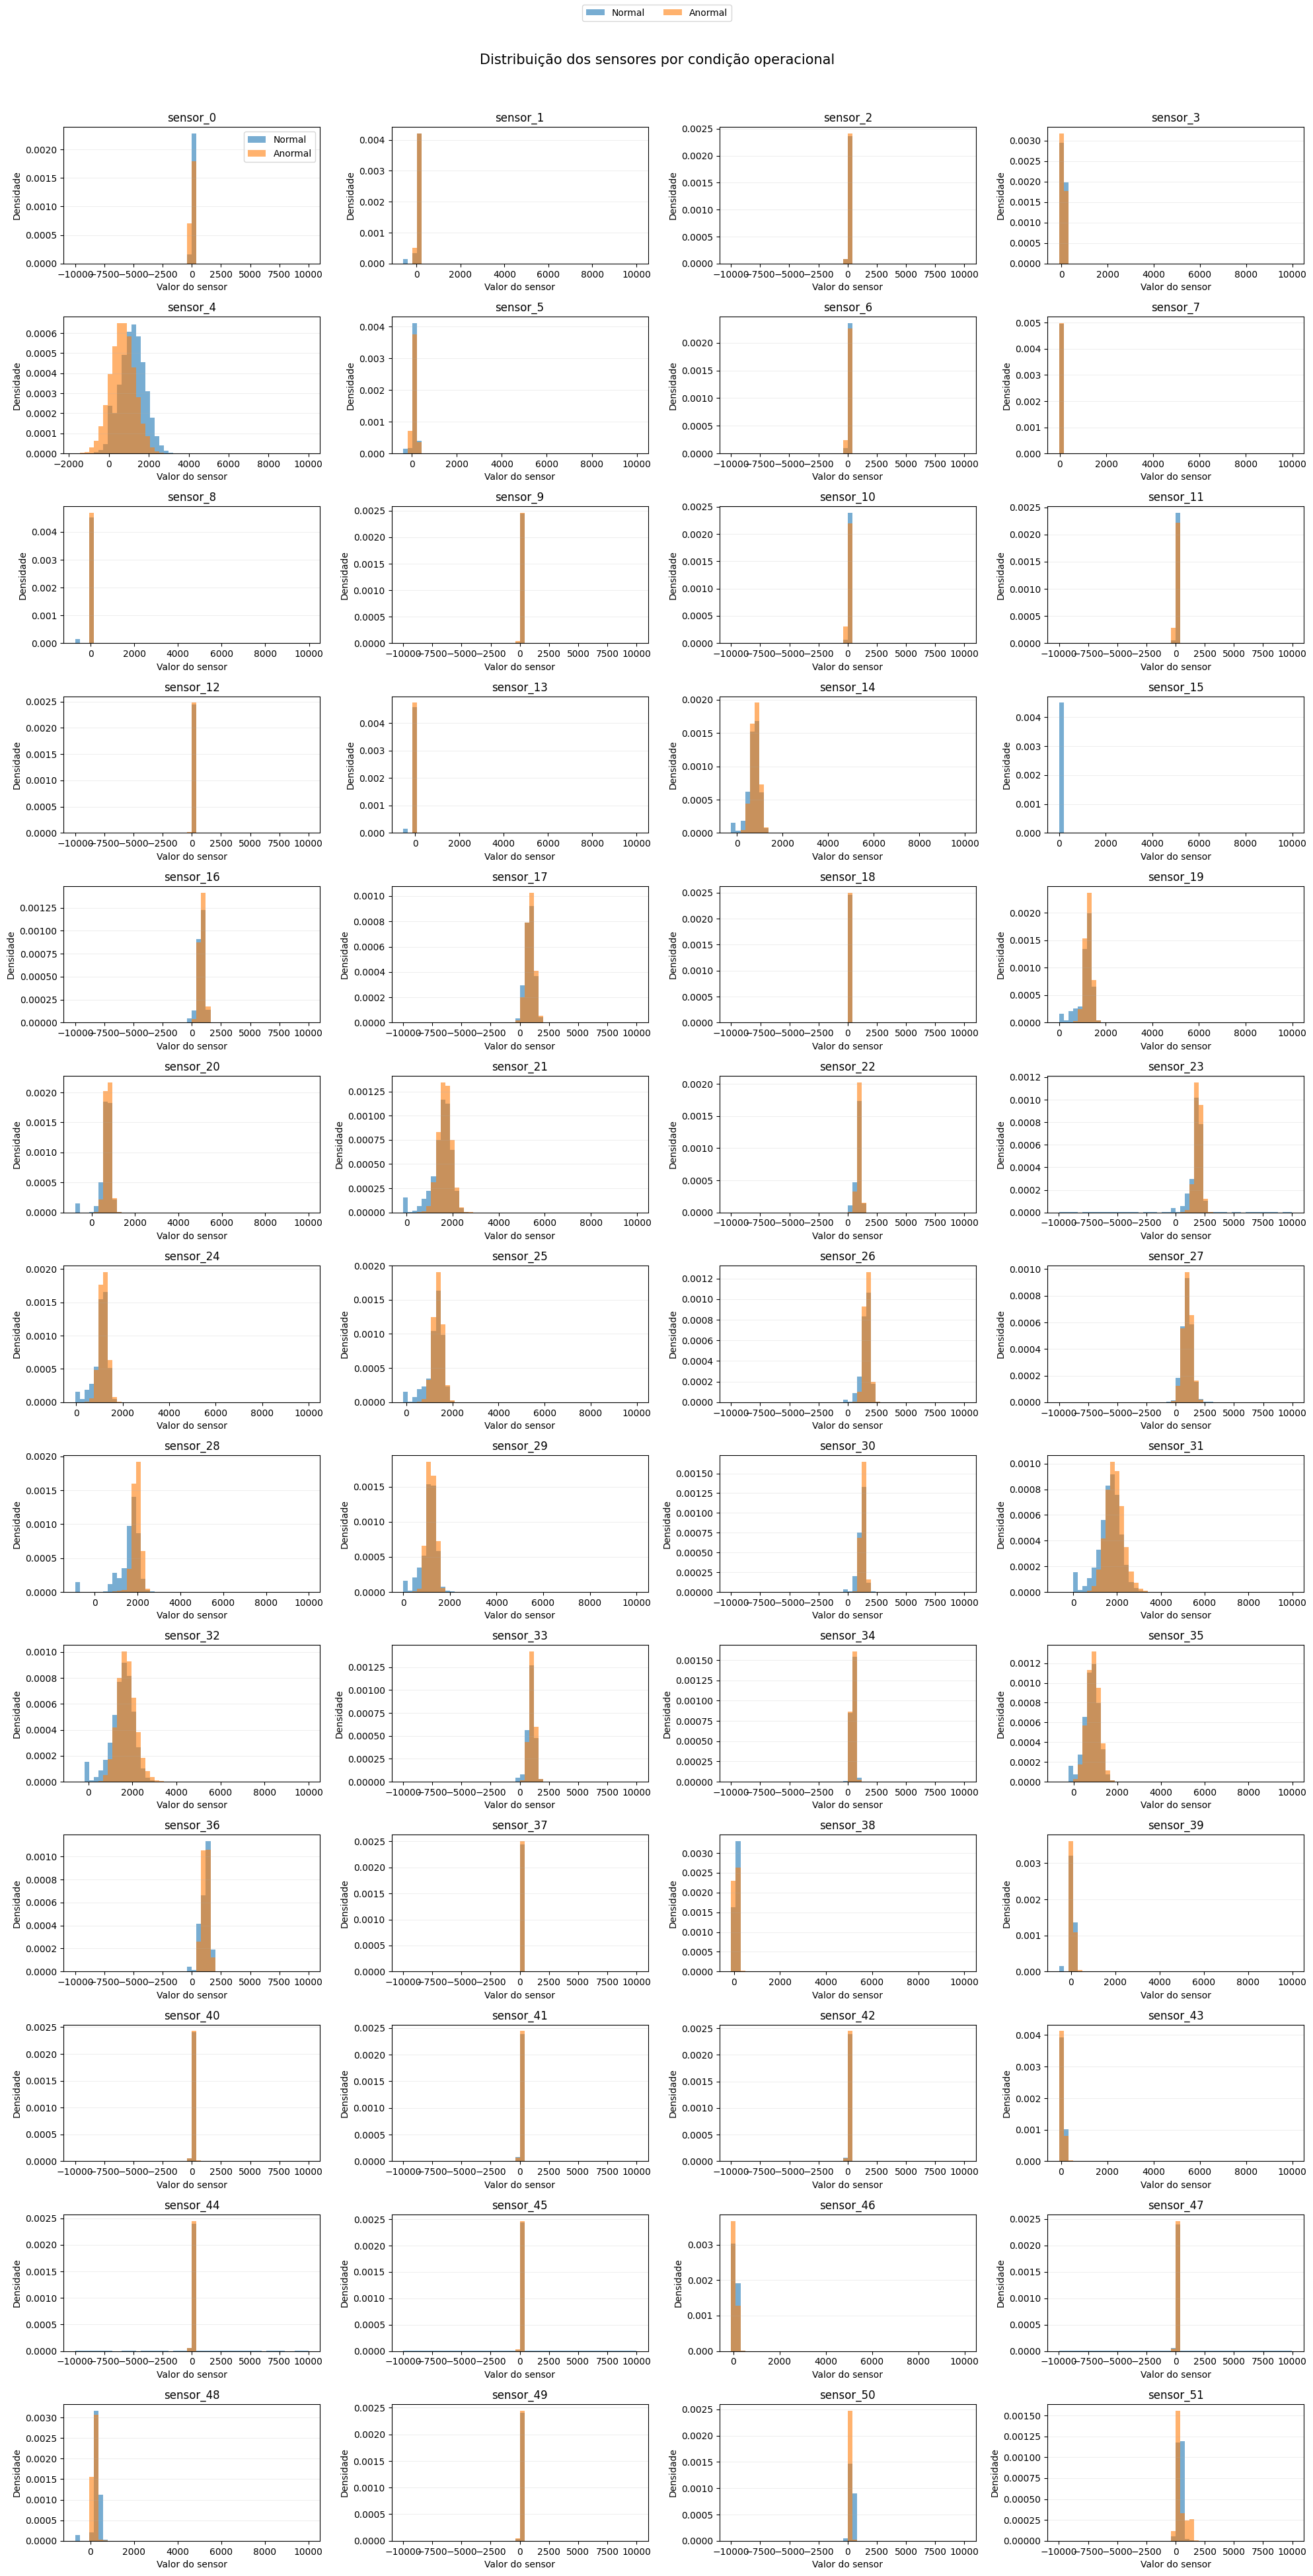

In [17]:
plotar_distribuicoes_sensores(
    industry_df,
    comparar_target=True,
    bins=50,
    ncols=4,
    density=True
)

Plotamos os histogramas normais, normalizados e pra cada classe. O histograma que mostra as distribuições pra cada classe separada é o mais importante deles, pois nos dá uma indicação visual de que as distribuições de dados em períodos de falhas é diferente da distribuição em períodos normais. Isso nos permitirá criar hipóteses futuramente.

Nos próximos notebooks iremos investigar melhor o comportamento dos sensores.